# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"azmifalah","key":"b048c134a707b00e6128eb0558f1bb60"}'}

In [3]:
# Download kaggle dataset and unzip the file
!mkdir -p ~/.kaggle/
!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d ishanshrivastava28/tata-online-retail-dataset
!unzip tata-online-retail-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/ishanshrivastava28/tata-online-retail-dataset
License(s): DbCL-1.0
  0% 0.00/29.0M [00:00<?, ?B/s]
100% 29.0M/29.0M [00:00<00:00, 2.15GB/s]
Archive:  tata-online-retail-dataset.zip
  inflating: Online Retail Data Set.csv  
  inflating: Online Retail Data Set.xlsx  


In [4]:
df = pd.read_csv('/content/Online Retail Data Set.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# Preprocessing Data

Untuk preprcossing disini kami melakukan beberapa langkah, yaitu :
- Menghapus Outlier
- Menghapus baris kosong dari `CustomerID`
- Mengubah tipe data pada kolom `InvoiceDate`
- Memfilter baris dengan `Quantity` negatif atau minus
- Menghitung `TotalPrice` dengan mengalikan `Quantity` dan `UnitPrice`

## Penanganan Outlier

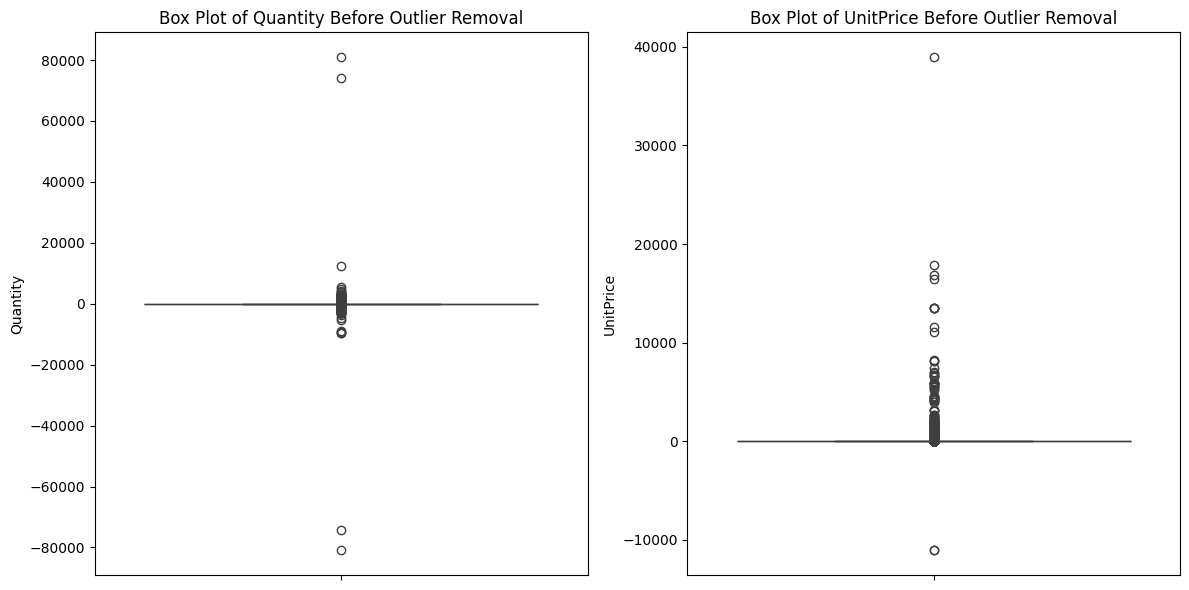

In [8]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Quantity'])
plt.title('Box Plot of Quantity Before Outlier Removal')
plt.ylabel('Quantity')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['UnitPrice'])
plt.title('Box Plot of UnitPrice Before Outlier Removal')
plt.ylabel('UnitPrice')

plt.tight_layout()
plt.show()

In [9]:
Q1_quantity = df['Quantity'].quantile(0.25)
Q3_quantity = df['Quantity'].quantile(0.75)
IQR_quantity = Q3_quantity - Q1_quantity

Q1_unitprice = df['UnitPrice'].quantile(0.25)
Q3_unitprice = df['UnitPrice'].quantile(0.75)
IQR_unitprice = Q3_unitprice - Q1_unitprice

lower_bound_quantity = Q1_quantity - 1.5 * IQR_quantity
upper_bound_quantity = Q3_quantity + 1.5 * IQR_quantity

lower_bound_unitprice = Q1_unitprice - 1.5 * IQR_unitprice
upper_bound_unitprice = Q3_unitprice + 1.5 * IQR_unitprice

df_cleaned = df[
    (df['Quantity'] >= lower_bound_quantity) & (df['Quantity'] <= upper_bound_quantity) &
    (df['UnitPrice'] >= lower_bound_unitprice) & (df['UnitPrice'] <= upper_bound_unitprice)
]

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after IQR outlier removal: {df_cleaned.shape}")

Original DataFrame shape: (541909, 8)
DataFrame shape after IQR outlier removal: (444108, 8)


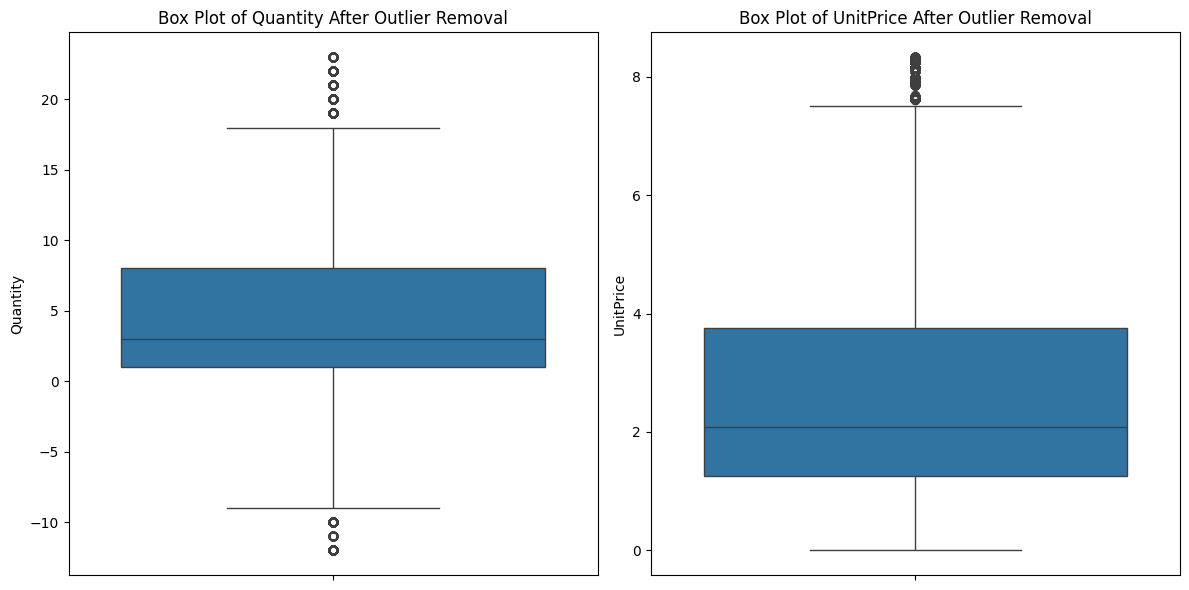

In [10]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_cleaned['Quantity'])
plt.title('Box Plot of Quantity After Outlier Removal')
plt.ylabel('Quantity')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['UnitPrice'])
plt.title('Box Plot of UnitPrice After Outlier Removal')
plt.ylabel('UnitPrice')

plt.tight_layout()
plt.show()

## Menghapus baris dengan CustomerID yang kosong

In [11]:
shape_before_nan_removal = df_cleaned.shape
df_cleaned = df_cleaned.dropna(subset=['CustomerID'])

print(f"DataFrame shape before removing NaN CustomerID: {shape_before_nan_removal}")
print(f"DataFrame shape after removing NaN CustomerID: {df_cleaned.shape}")

DataFrame shape before removing NaN CustomerID: (444108, 8)
DataFrame shape after removing NaN CustomerID: (327498, 8)


## Mengubah tipe data InvoiceDate menjadi _datetime_

In [12]:
df_cleaned = df_cleaned.copy()
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'],
                                                       format='%d-%m-%Y %H:%M')

In [14]:
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

print(f"Data type of 'InvoiceDate' after conversion: {df_cleaned['InvoiceDate'].dtype}")

Data type of 'InvoiceDate' after conversion: datetime64[ns]


## Memfilter baris dengan Quantity dan UnitPrice negatif atau nol

In [15]:
shape_before_positive_filter = df_cleaned.shape

df_cleaned = df_cleaned[
    (df_cleaned['Quantity'] > 0) & (df_cleaned['UnitPrice'] > 0)
]

print(f"DataFrame shape before filtering for positive Quantity and UnitPrice: {shape_before_positive_filter}")
print(f"DataFrame shape after filtering for positive Quantity and UnitPrice: {df_cleaned.shape}")

DataFrame shape before filtering for positive Quantity and UnitPrice: (327498, 8)
DataFrame shape after filtering for positive Quantity and UnitPrice: (321007, 8)


## Menghitung TotalPrice untuk setiap transaksi

In [16]:
df_cleaned = df_cleaned.copy()
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

print("New 'TotalPrice' column created successfully.")
print(df_cleaned[['Quantity', 'UnitPrice', 'TotalPrice']].head())

New 'TotalPrice' column created successfully.
   Quantity  UnitPrice  TotalPrice
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34


In [17]:
df_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Menyimpan dataset yang sudah dibersihkan

In [18]:
df_cleaned.to_csv('preprocessed_retail_data.csv', index=False)

In [19]:
df_cleaned.shape

(321007, 9)